In [8]:

%pip install kaggle
%pip install kagglehub
%pip install -Uq fastkaggle
import fastai
from fastkaggle import *
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_67c82fb30c76d3592439bb44a9504e0f"
comp = 'paddy-disease-classification'

path = setup_comp(comp, install='fastai "timm>=0.6.2.dev0"')

100%|██████████| 1.02G/1.02G [00:06<00:00, 179MB/s]


In [9]:
path

Path('paddy-disease-classification')

In [10]:
from fastai.vision.all import *
set_seed(42)
path.ls()

[Path('paddy-disease-classification/test_images'), Path('paddy-disease-classification/train_images'), Path('paddy-disease-classification/train.csv'), Path('paddy-disease-classification/sample_submission.csv')]

In [11]:
!ls {path}

sample_submission.csv  test_images  train.csv  train_images


In [12]:
trn_path = path/'train_images'
files =  get_image_files(trn_path)

(480, 640)


<Axes: >

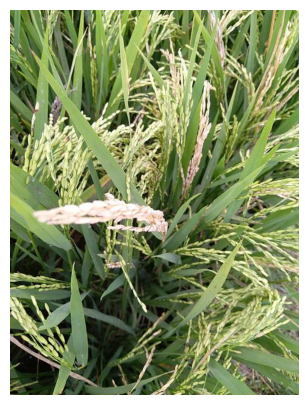

In [16]:
img = PILImage.create(files[0])
print(img.size)
img.show()

In [17]:
from fastcore.parallel import *
def f(o):
    return PILImage.create(o).size
sizes = parallel(f, files, n_workers  = 8)

pd.Series(sizes).value_counts()

,count
"(480, 640)",10403
"(640, 480)",4


In [18]:
!nvidia-smi


/bin/bash: line 1: nvidia-smi: command not found


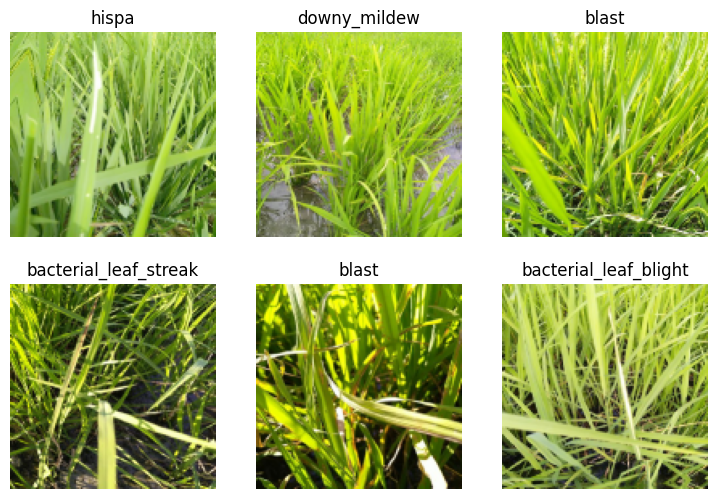

In [19]:
dls = ImageDataLoaders.from_folder(trn_path, valid_pct=0.2, seed=42,
    item_tfms=Resize(480, method='squish'),
    batch_tfms=aug_transforms(size=128, min_scale=0.75))

dls.show_batch(max_n=6)